## Imports

In [1]:
from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

MARKOV_STEPS = 500


## Process Initial Data

In [2]:
# read voter district map and mggg community cluster map
vtds = gpd.read_file("data/mo_2020_vtd/mo_2020.shp")
cois = gpd.read_file("data/mo_2021_coi/MO_20210924_phase_C_summary.shp")

# find subclusters to drop parents
subclusters = cois[cois['cluster'].str.contains('-')]
parents_to_drop = subclusters['cluster'].apply(lambda x: x.split('-')[0]).unique()
cois = cois[~cois['cluster'].isin(parents_to_drop)]

# align coords on both maps
if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)

## datas missing a total pop column, so add up presidential votes to get
pres_cols = ['G20PRERTRU', 'G20PREDBID', 'G20PRELJOR', 'G20PREGHAW', 'G20PRECBLA']
vtds['TOTPOP'] = vtds[pres_cols].sum(axis=1)

## now need coi fractions per vtd
# what fraction of community resides here? coi area / total area
vtds['vtd_area'] = vtds.geometry.area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

# drop tiny overlaps
clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

# figure out num people from overlaps pct
clean_overlaps['coi_pop'] = clean_overlaps['TOTPOP'] * clean_overlaps['coi_fraction']

# build coi pop dict per vtd
coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME']
    cluster_id = row['cluster']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = population_chunk

vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME']]

In [3]:
#print(vtds.columns)
#(vtds.head(1))
display(vtds[['NAME', 'TOTPOP', 'COI_POPS']].head(10))
#vtds.to_csv('vtds.csv', columns=['NAME','TOTPOP','COI_POPS'])

,NAME,TOTPOP,COI_POPS
0,Commerce,376,{'C29': 375.99348264324686}
1,West Finley,2221,"{'C27-1': 887.9613364658306, 'C27-2': 1148.053..."
2,Huntsville,687,{'C20': 687.0000000000003}
3,Barry East,2656,"{'C14': 2656.0, 'C13': 2656.0}"
4,California 3,871,{'C20': 871.0000000000003}
5,Marquand,498,{'C29': 324.5919238633417}
6,Wellsville,744,{'C22': 744.0000000000003}
7,Foristell,2041,"{'C1': 2040.9999999999977, 'C7': 2040.99999999..."
8,Warrenton 3,1081,"{'C1': 1081.0000000000016, 'C7': 1081.00000000..."
9,KC 21 Gallatin 4,1322,"{'C14': 1322.0, 'C13': 1322.0}"


## Markov Chaining

### Helpers

In [4]:

def extract_data(partition):
    data_rows = []

    for node_id in partition.graph.nodes:
        assigned_dist = partition.assignment[node_id]
        # grab the dict with community pop info
        node_cois = partition.graph.nodes[node_id].get("COI_POPS", {})
        for coi_id, coi_pop in node_cois.items():
            data_rows.append(
                {
                    #TODO: no categories for this data so just 1 'coi' bucket, maybe NLP will give us categories later
                    "category": "coi",
                    "community_id": coi_id,
                    "district": assigned_dist,
                    "pop": coi_pop,
                }
            )

    return pd.DataFrame(data_rows)




### Updaters (Scoring)

In [5]:
def score_communities(unscored_df):
    """
    calculates the sum of squared shares for each community

    inputs:
        unscored_df: df with cols: category, community_id, district, pop
    outputs:
        communities_scores: df with cols: category, community_id, total_pop, sss_score
    """
    # get total pop per community (water1, water2..)
    total_pops = unscored_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
    total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

    # get pop per community and district
    district_splits = unscored_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()

    # merge to get pop / total pop
    merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

    # get squared shares
    merged['share'] = merged['pop'] / merged['total_pop']
    merged['squared_share'] = merged['share'] ** 2

    # sum squared shares across all communities in each category
    # this is the 'final' score for each community (not grouped yet)
    final_sss_df = merged.groupby(['category', 'community_id', 'total_pop'])['squared_share'].sum().reset_index()
    final_sss_df.rename(columns={'squared_share': 'sss_score'}, inplace=True)
    return final_sss_df

def score_overall(dataframe, weights):
    """
    calculates the total coi preservation as a single metric between 0 and 1

    inputs:
        dataframe: output from score_communities()
        weights: dict with keys: category, values: weight
    outputs:
        final_score: total coi preservation (tcp) between 0 and 1
    """
    # after getting sss score for each community, we want 1 final metric
    # bigger populations need more weight in category averages
    # get pop weighted avg for each community - sum(pop[i] * coi score / category pop
    dataframe['weighted_score'] = dataframe['sss_score'] * dataframe['total_pop']
    category_score_sums = dataframe.groupby('category')['weighted_score'].sum()
    category_pop_sums = dataframe.groupby('category')['total_pop'].sum()

    # gets our category averages
    pop_weighted_avg = category_score_sums / category_pop_sums
    # multiply each category score by weight and sum for final metric
    final_score = (pop_weighted_avg * pd.Series(weights)).sum()
    return final_score

def calculate_tcp(partition):
    # arbitrary
    #weights = {'water': 0.5, 'county': 0.3, 'muni': 0.2}
    # TODO: get NLP to categorize and weight
    weights = {'coi': 1}

    raw_df = extract_data(partition)
    community_scores = score_communities(raw_df)
    final_score = score_overall(community_scores, weights)
    
    return final_score

def count_dem_wins(partition):
    dem_wins = 0
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['G20PREDBID']
            tot_pop += node_attrs['TOTPOP']
            
        if dem_pop / tot_pop > 0.5:
            dem_wins += 1

    return dem_wins

### Init Graph and Chain

In [6]:
## init graph
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

# missouri has 8 districts
total_population = sum(node.get('TOTPOP', 1) for node in g.nodes.values())
target_pop = total_population / 8

# using a gerrychain method to start with 8 equal nice contiguous parts
starting_assignment = recursive_tree_part(
    g, 
    parts=range(8), 
    pop_target=target_pop, 
    pop_col="TOTPOP", 
    epsilon=0.05
)

## init part
initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters={ 
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins
    }
)

## init chain
proposal = partial(recom, pop_col="TOTPOP", pop_target=target_pop, epsilon=0.05, node_repeats=2)
chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

/Users/jevonlipsey/miniconda3/envs/mcure/lib/python3.12/site-packages/gerrychain/graph/adjacency.py:112: UserWarning: Found overlaps among the given polygons. Indices of overlaps: {(3097, 3358), (3691, 3692), (521, 1469), (2399, 3085), (1257, 3721), (2210, 2593), (2818, 2823), (3695, 3697), (3696, 3697), (1392, 1773), (526, 1773), (3709, 3717), (3721, 3722), (1257, 3722), (1689, 1782), (3672, 3673), (2593, 3119), (674, 1773), (3693, 3694), (1617, 1843)}
  warnings.warn(


### Run Chain

In [7]:
# collect scores
tcp_scores = []
cut_edges_count = []
dem_wins_count = []
best_score=0
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0

for partition in chain:
    score = partition['tcp_score']
    cuts = len(partition['cut_edges'])
    seats = partition['dem_wins']

    tcp_scores.append(score)
    cut_edges_count.append(cuts)
    dem_wins_count.append(seats)

    # track most preserved
    if score > best_score:
        best_score = score
        best_map = partition
        
    # track least preserved
    if score < worst_score:
        worst_score = score
        worst_map = partition

    # track overall best
    if seats > most_seats:
        most_seats = seats
        overall_best_score = score
        overall_best_map = partition
    elif seats == most_seats:
        if score > overall_best_score:
            overall_best_score = score
            overall_best_map = partition

## Missouri's Aggregated Communities Map

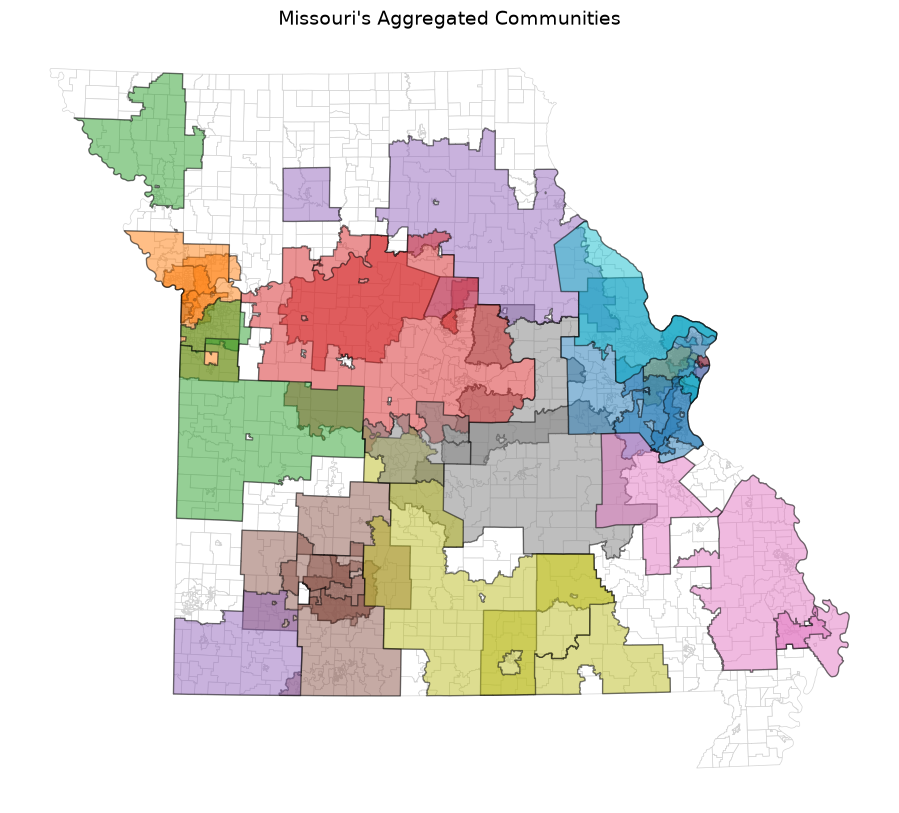

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))

vtds.plot(ax=ax, color="white", edgecolor="lightgray", linewidth=0.5)
cois.plot(ax=ax, column="cluster", alpha=0.5, edgecolor="black")

ax.set_title("Missouri's Aggregated Communities", fontsize=14)
ax.axis("off")
plt.show()

## Graphs

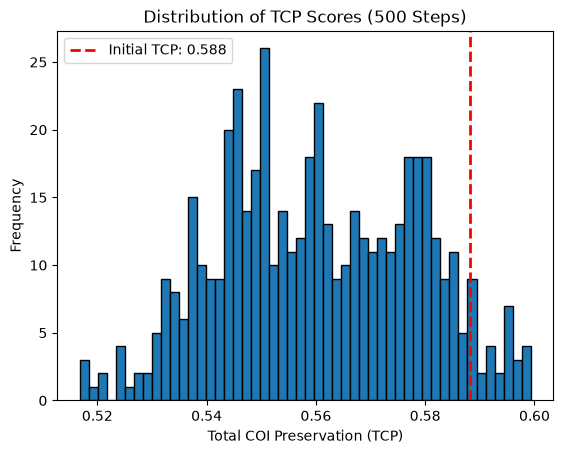

In [9]:
# hist: tcp scores distribution
plt.hist(tcp_scores, bins=50, edgecolor="black")
initial_score = initial_partition["tcp_score"]
plt.axvline(
    initial_score,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial TCP: {initial_score:.3f}",
)

plt.title(f"Distribution of TCP Scores ({MARKOV_STEPS} Steps)")
plt.xlabel("Total COI Preservation (TCP)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

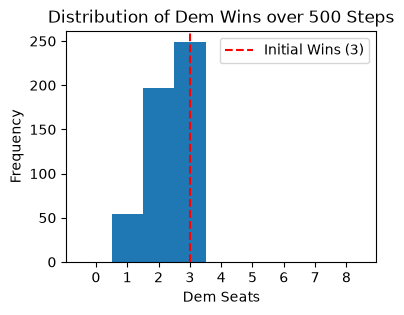

In [10]:
# hist: dem seats distribution
n_districts = len(initial_partition.parts)
plt.figure(figsize=(4,3))
plt.hist(
    dem_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("Dem Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of Dem Wins over {MARKOV_STEPS} Steps")

# initial wins line
initial_wins = count_dem_wins(initial_partition)
plt.axvline(x=initial_wins, color='red', linestyle='dashed', label=f'Initial Wins ({initial_wins})')

plt.legend()
plt.show()

In [11]:
def plot_partition(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    vtds.plot(ax=ax, column="district", cmap='Pastel1',edgecolor="black", linewidth=0.15)
    #cois.plot(ax=ax, column="cluster", facecolor='none', edgecolor="red", linewidth=0.15)

    for district in vtds['district'].unique():
        district_geoms = vtds[vtds['district'] == district].geometry
        combined = district_geoms.unary_union
        rep_point = combined.representative_point()
    
        ax.text(rep_point.x, rep_point.y, str(district), 
                fontsize=14, fontweight='bold', color='black', ha='center')

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

plotting most preserved map:
tcp score: 0.599
cut edges: 528
dem seats won: 1/8


/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: T

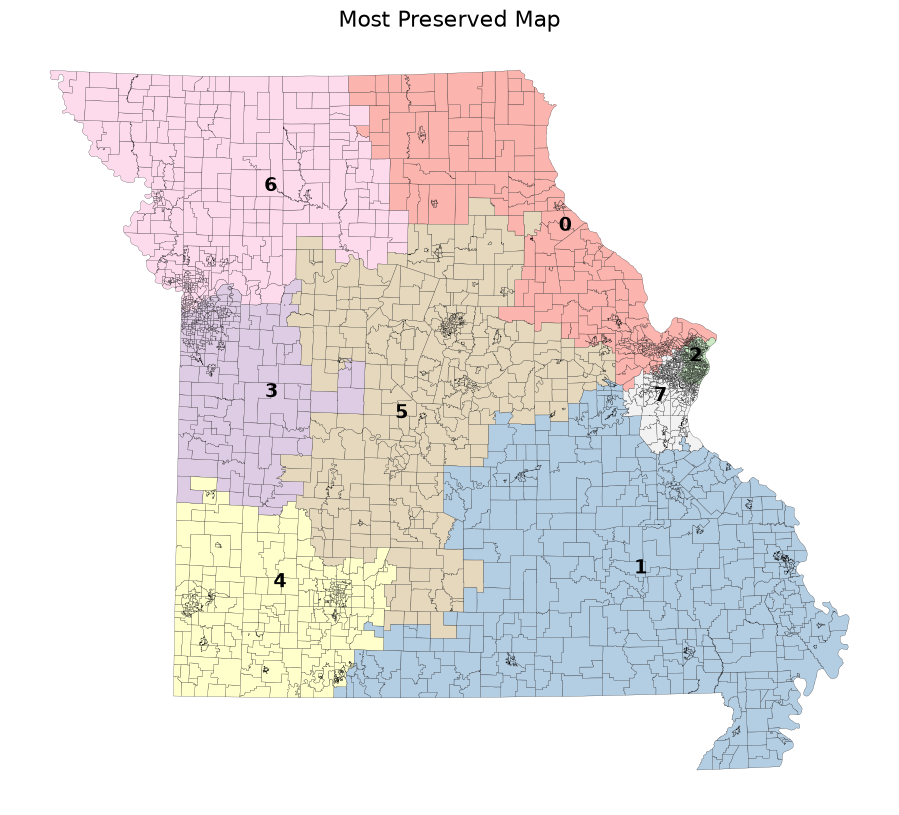

plotting least preserved map:
tcp score: 0.517
cut edges: 678
dem seats won: 2/8


/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: T

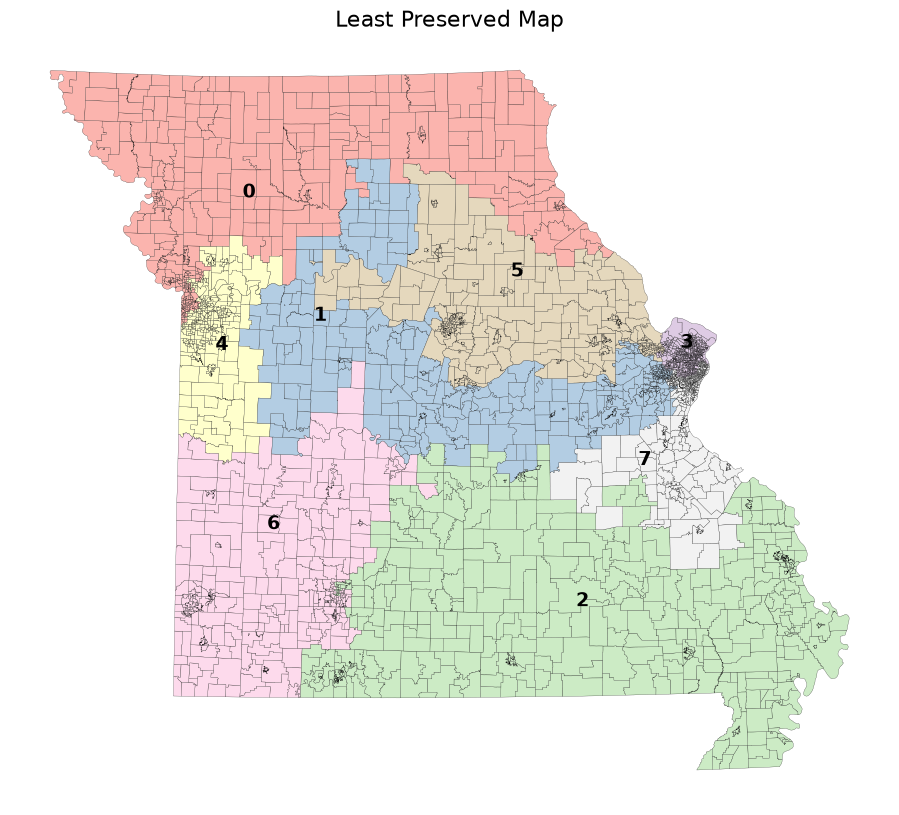

plotting best max representation map:
tcp score: 0.599
cut edges: 567
dem seats won: 3/8


/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined = district_geoms.unary_union
/var/folders/mt/160p71wx0z9842776nfyc85r0000gn/T/ipykernel_10743/3033069798.py:12: DeprecationWarning: T

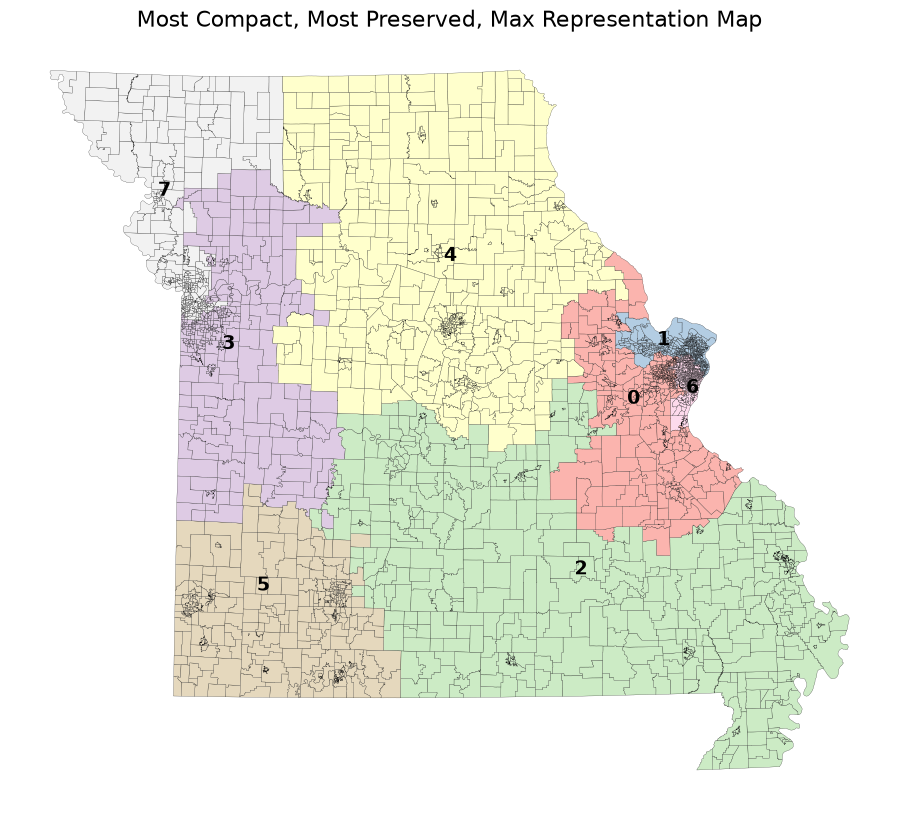

In [12]:
# plotted partition maps
print("plotting most preserved map:")
print(f"tcp score: {best_map['tcp_score']:.3f}")
print(f"cut edges: {len(best_map['cut_edges'])}")
print(f"dem seats won: {best_map['dem_wins']}/8")
plot_partition(best_map, vtds, cois, 'Most Preserved Map')

print("plotting least preserved map:")
print(f"tcp score: {worst_map['tcp_score']:.3f}")
print(f"cut edges: {len(worst_map['cut_edges'])}")
print(f"dem seats won: {worst_map['dem_wins']}/8")
plot_partition(worst_map, vtds, cois, 'Least Preserved Map')

print("plotting best max representation map:")
print(f"tcp score: {overall_best_map['tcp_score']:.3f}")
print(f"cut edges: {len(overall_best_map['cut_edges'])}")
print(f"dem seats won: {overall_best_map['dem_wins']}/8")
plot_partition(overall_best_map, vtds, cois, 'Most Compact, Most Preserved, Max Representation Map')